# CNN-1D Models for HAR — MotionSense

Convolutional networks operating directly on raw (128, 12) IMU windows.
Subject-independent split: subjects 0–14 train, 15–18 validation, 19–23 test.
Primary metric: **macro-F1**. Secondary: accuracy.

Target to beat: classical statistical-feature pipeline (SVC-RBF, top-72 RF-importance features, tuned) — macro-F1 = 0.9519. The classical approach aggregates each axis to scalars and discards intra-window temporal ordering; CNN-1D operates directly on the time series and can capture the asymmetric ground-contact pattern of stair descent vs. ascent (the residual confusion cluster identified in the baseline notebook).

> Yang, J., Nguyen, M. N., San, P. P., Li, X. L., & Krishnaswamy, S. (2015). Deep convolutional neural networks on multichannel time series for human activity recognition. *IJCAI 2015*, 3995–4001.
> Ronao, C. A., & Cho, S.-B. (2016). Human activity recognition with smartphone sensors using deep learning neural networks. *Expert Systems with Applications*, 59, 235–244. https://doi.org/10.1016/j.eswa.2016.04.032


## Section 1 — Reload data

Loader functions (`get_ds_infos`, `set_data_types`, `create_time_series`,
`sliding_windows`) are reused unchanged from `baseline.ipynb` so that subject
indexing, axis ordering, and the windowing scheme remain identical across
notebooks. The subject-independent split is extended here: **4 subjects
(15–18) are held out from training as validation** instead of using a random
validation split. Windows overlap by 50% (step = 64), so a random split would
leak ~50% of every training window into validation, optimistically biasing
`val_loss` and rendering early stopping meaningless (Hammerla et al., 2016,
§3 on subject-wise evaluation in HAR).

> Hammerla, N. Y., Halloran, S., & Plötz, T. (2016). Deep, convolutional, and recurrent models for human activity recognition using wearables. *IJCAI 2016*, 1533–1540.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f'TensorFlow {tf.__version__}')


TensorFlow 2.21.0


In [2]:
ACT_LABELS = ["dws", "ups", "wlk", "jog", "std", "sit"]

TRIAL_CODES = {
    ACT_LABELS[0]: [1, 2, 11],
    ACT_LABELS[1]: [3, 4, 12],
    ACT_LABELS[2]: [7, 8, 15],
    ACT_LABELS[3]: [9, 16],
    ACT_LABELS[4]: [6, 14],
    ACT_LABELS[5]: [5, 13],
}

_feature_cols = [
    'attitude.roll', 'attitude.pitch', 'attitude.yaw',
    'gravity.x', 'gravity.y', 'gravity.z',
    'rotationRate.x', 'rotationRate.y', 'rotationRate.z',
    'userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z',
]


In [3]:
def get_ds_infos():
    dss = pd.read_csv("../data/data_subjects_info.csv")
    print("[INFO] -- Data subjects' information is imported.")
    return dss


def set_data_types(data_types=["userAcceleration"]):
    dt_list = []
    for t in data_types:
        if t != "attitude":
            dt_list.append([t + ".x", t + ".y", t + ".z"])
        else:
            dt_list.append([t + ".roll", t + ".pitch", t + ".yaw"])
    return dt_list


def create_time_series(dt_list, act_labels, trial_codes, mode="mag", labeled=True):
    num_data_cols = len(dt_list) if mode == "mag" else len(dt_list) * 3
    dataset = np.zeros((0, num_data_cols + 7)) if labeled else np.zeros((0, num_data_cols))
    ds_list = get_ds_infos()
    print("[INFO] -- Creating Time-Series")
    for sub_id in ds_list["code"]:
        for act_id, act in enumerate(act_labels):
            for trial in trial_codes[act]:
                fname = ('../data/A_DeviceMotion_data/' + act + '_' + str(trial)
                         + '/sub_' + str(int(sub_id)) + '.csv')
                raw_data = pd.read_csv(fname).drop(['Unnamed: 0'], axis=1)
                vals = np.zeros((len(raw_data), num_data_cols))
                for x_id, axes in enumerate(dt_list):
                    if mode == "mag":
                        vals[:, x_id] = (raw_data[axes] ** 2).sum(axis=1) ** 0.5
                    else:
                        vals[:, x_id * 3:(x_id + 1) * 3] = raw_data[axes].values
                vals = vals[:, :num_data_cols]
                if labeled:
                    lbls = np.array([[act_id,
                                      sub_id - 1,
                                      ds_list["weight"][sub_id - 1],
                                      ds_list["height"][sub_id - 1],
                                      ds_list["age"][sub_id - 1],
                                      ds_list["gender"][sub_id - 1],
                                      trial]] * len(raw_data))
                    vals = np.concatenate((vals, lbls), axis=1)
                dataset = np.append(dataset, vals, axis=0)
    cols = []
    for axes in dt_list:
        cols += axes if mode == "raw" else [str(axes[0][:-2])]
    if labeled:
        cols += ["act", "id", "weight", "height", "age", "gender", "trial"]
    return pd.DataFrame(data=dataset, columns=cols)


def sliding_windows(data: pd.DataFrame, window_size: int = 128, step: int = 64,
                    feature_cols: list = _feature_cols):
    """Sliding window segmentation over (subject, activity, trial) groups."""
    X, y = [], []
    for (_, act, _), group in data.groupby(['id', 'act', 'trial']):
        vals = group[feature_cols].values
        for start in range(0, len(vals) - window_size + 1, step):
            X.append(vals[start:start + window_size])
            y.append(act)
    return np.array(X), np.array(y)


In [4]:
sdt = ["attitude", "gravity", "rotationRate", "userAcceleration"]
dt_list = set_data_types(sdt)
dataset = create_time_series(dt_list, ACT_LABELS, TRIAL_CODES, mode="raw", labeled=True)
dataset['act'] = dataset['act'].astype(int)
dataset['id']  = dataset['id'].astype(int)

# Train: 0-14 (15 subj.), Val: 15-18 (4 subj.), Test: 19-23 (5 subj.)
# Splitting at the DataFrame level (before windowing) so that no subject leaks
# across split boundaries via overlapping windows.
train_ids = list(range(0, 15))
val_ids   = list(range(15, 19))
test_ids  = list(range(19, 24))

df_train = dataset[dataset['id'].isin(train_ids)].copy()
df_val   = dataset[dataset['id'].isin(val_ids)].copy()
df_test  = dataset[dataset['id'].isin(test_ids)].copy()

X_train, y_train = sliding_windows(df_train, window_size=128, step=64)
X_val,   y_val   = sliding_windows(df_val,   window_size=128, step=64)
X_test,  y_test  = sliding_windows(df_test,  window_size=128, step=64)
y_train = y_train.astype(int)
y_val   = y_val.astype(int)
y_test  = y_test.astype(int)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
print(f"Train class counts: {dict(zip(ACT_LABELS, np.bincount(y_train)))}")


[INFO] -- Data subjects' information is imported.
[INFO] -- Creating Time-Series
X_train: (13282, 128, 12), y_train: (13282,)
X_val:   (3905, 128, 12), y_val:   (3905,)
X_test:  (4352, 128, 12), y_test:  (4352,)
Train class counts: {'dws': np.int64(1168), 'ups': np.int64(1385), 'wlk': np.int64(3231), 'jog': np.int64(1241), 'std': np.int64(2882), 'sit': np.int64(3375)}


## Section 2 — Preprocessing: Single-Input Mixed Normalization

**Mixed normalization strategy** is applied to the 12-channel input windows.
The 128-sample windows are processed as follows:

- **Static Channels (0–5)**: `attitude.*` and `gravity.*` remain **raw**. These channels carry the absolute orientation and posture information (DC offset), which is critical for distinguishing static activities like sitting vs. standing.
- **Dynamic Channels (6–11)**: `rotationRate.*` and `userAcceleration.*` undergo **instance-wise Z-score normalization** along the time axis. This preserves the shape of the motion dynamics while neutralizing cross-device/cross-subject scale variations (Stisen et al., 2015).

This "Single-Input Mixed" approach provides the CNN with both the high-frequency motion patterns and the low-frequency posture context in a single (128, 12) tensor.

> Stisen, A., Blunck, H., Bhattacharya, S., et al. (2015). Smart devices are different: Assessing and mitigating mobile sensing heterogeneities for activity recognition. *Proceedings of SenSys 2015*, 127–140.


In [5]:
def mixed_instance_zscore(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """Per-window normalization: Raw for channels 0-5, Z-score for channels 6-11."""
    # Split into static and dynamic
    X_static  = X[:, :, 0:6]   # (N, 128, 6)
    X_dynamic = X[:, :, 6:12]  # (N, 128, 6)
    
    # Z-score only the dynamic channels
    mean = X_dynamic.mean(axis=1, keepdims=True)  # (N, 1, 6)
    std  = X_dynamic.std(axis=1, keepdims=True)   # (N, 1, 6)
    X_dynamic_n = (X_dynamic - mean) / (std + eps)
    
    return np.concatenate([X_static, X_dynamic_n], axis=2)


X_train_n = mixed_instance_zscore(X_train)
X_val_n   = mixed_instance_zscore(X_val)
X_test_n  = mixed_instance_zscore(X_test)

print(f"X_train_n: {X_train_n.shape}")
print(f"  Static (0-5)  mean: {X_train_n[:, :, 0:6].mean():.4f}")
print(f"  Dynamic (6-11) mean: {X_train_n[:, :, 6:12].mean():.2e}")


X_train_n: (13282, 128, 12)
  Static (0-5)  mean: -0.0978
  Dynamic (6-11) mean: -1.16e-18


## Section 3 — Baseline CNN-1D architecture

Three 1-D convolutional blocks with progressively narrower receptive fields
(5 → 5 → 3), each followed by batch normalisation and max-pooling, then global
average pooling and a small dense head. This follows the standard CNN-1D
template for HAR introduced by Yang et al. (2015) and refined by Ronao & Cho
(2016).

**Per-component justification:**

- **`Conv1D(kernel_size=5)` at the input** — covers ~100 ms at 50 Hz, the order of a single foot-strike impulse (Sabatini et al., 2005).
- **Two pooling stages (×2)** — receptive field at the GAP layer spans 32 raw samples (~640 ms), enough for one full stride period of jogging (~500 ms) and close to one of walking (~1000 ms) (Voloshin, 2000).
- **`BatchNormalization` after every conv** — stabilises gradients and accelerates convergence, especially under class imbalance with softmax cross-entropy (Ioffe & Szegedy, 2015).
- **`GlobalAveragePooling1D` instead of `Flatten`** — translation-invariant features, drastically fewer parameters and a smaller overfitting risk on a small dataset (Lin et al., 2014).
- **`Dropout(0.3)` before the softmax** — empirically the most reliable single regulariser on small HAR datasets (Srivastava et al., 2014).
- **`class_weight='balanced'`** — addresses the wlk/std/sit ↔ dws/jog/ups imbalance documented in EDA (section 2).
- **`Adam(lr=1e-3)`** — Kingma & Ba (2015); standard default for small/medium datasets without additional tuning.
- **`EarlyStopping(patience=10, restore_best_weights=True)`** — restores the best validation checkpoint at the end of training (Prechelt, 1998).

> Yang, J., Nguyen, M. N., San, P. P., Li, X. L., & Krishnaswamy, S. (2015). Deep convolutional neural networks on multichannel time series for human activity recognition. *IJCAI 2015*, 3995–4001.

> Ronao, C. A., & Cho, S.-B. (2016). Human activity recognition with smartphone sensors using deep learning neural networks. *Expert Systems with Applications*, 59, 235–244. https://doi.org/10.1016/j.eswa.2016.04.032

> Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network training by reducing internal covariate shift. *ICML 2015*, 448–456.

> Lin, M., Chen, Q., & Yan, S. (2014). Network in network. *ICLR 2014*. https://arxiv.org/abs/1312.4400

> Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *JMLR*, 15(56), 1929–1958.

> Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. *ICLR 2015*. https://arxiv.org/abs/1412.6980

> Prechelt, L. (1998). Early stopping — but when? In *Neural Networks: Tricks of the Trade* (pp. 55–69). Springer.

> Sabatini, A. M., Martelloni, C., Scapellato, S., & Cavallo, F. (2005). Assessment of walking features from foot inertial sensing. *IEEE TBME*, 52(3), 486–494.

> Voloshin, A. (2000). The influence of walking speed on dynamic loading on the human musculoskeletal system. *Medicine and Science in Sports and Exercise*, 32(6), 1156–1159.

In [6]:
# Inverse-frequency class weights: w_c = N / (K * n_c) for K classes.
_class_weights = compute_class_weight('balanced', classes=np.arange(6), y=y_train)
class_weight = {int(i): float(w) for i, w in enumerate(_class_weights)}
print('class_weight (balanced):')
for i, w in class_weight.items():
    print(f'  {ACT_LABELS[i]} (class {i}): {w:.3f}')


class_weight (balanced):
  dws (class 0): 1.895
  ups (class 1): 1.598
  wlk (class 2): 0.685
  jog (class 3): 1.784
  std (class 4): 0.768
  sit (class 5): 0.656


In [7]:
def build_cnn_baseline(input_shape=(128, 12), n_classes=6) -> keras.Model:
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inp, out, name='cnn_baseline')


tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)
cnn = build_cnn_baseline()
cnn.summary()
n_params_cnn = cnn.count_params()
print(f'Trainable parameters: {n_params_cnn:,}')


Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 12)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,838 (440.77 KB)

 Trainable params: 112,198 (438.27 KB)

 Non-trainable params: 640 (2.50 KB)

Trainable parameters: 112,838


In [8]:
cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

cb_cnn = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=1),
]

history_cnn = cnn.fit(
    X_train_n, y_train,
    validation_data=(X_val_n, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weight,
    callbacks=cb_cnn,
    verbose=2,
)


Epoch 1/100
416/416 - 6s - 15ms/step - accuracy: 0.9069 - loss: 0.3519 - val_accuracy: 0.7682 - val_loss: 0.9370 - learning_rate: 0.0010
Epoch 2/100
416/416 - 4s - 10ms/step - accuracy: 0.9799 - loss: 0.0858 - val_accuracy: 0.8338 - val_loss: 0.7840 - learning_rate: 0.0010
Epoch 3/100
416/416 - 4s - 10ms/step - accuracy: 0.9867 - loss: 0.0547 - val_accuracy: 0.8044 - val_loss: 0.8502 - learning_rate: 0.0010
Epoch 4/100
416/416 - 6s - 14ms/step - accuracy: 0.9889 - loss: 0.0406 - val_accuracy: 0.7713 - val_loss: 1.0079 - learning_rate: 0.0010
Epoch 5/100
416/416 - 4s - 10ms/step - accuracy: 0.9934 - loss: 0.0244 - val_accuracy: 0.7946 - val_loss: 1.0435 - learning_rate: 0.0010
Epoch 6/100
416/416 - 4s - 10ms/step - accuracy: 0.9924 - loss: 0.0270 - val_accuracy: 0.8166 - val_loss: 1.0503 - learning_rate: 0.0010
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
416/416 - 5s - 12ms/step - accuracy: 0.9934 - loss: 0.0251 - val_accuracy: 0.8087 - val_l

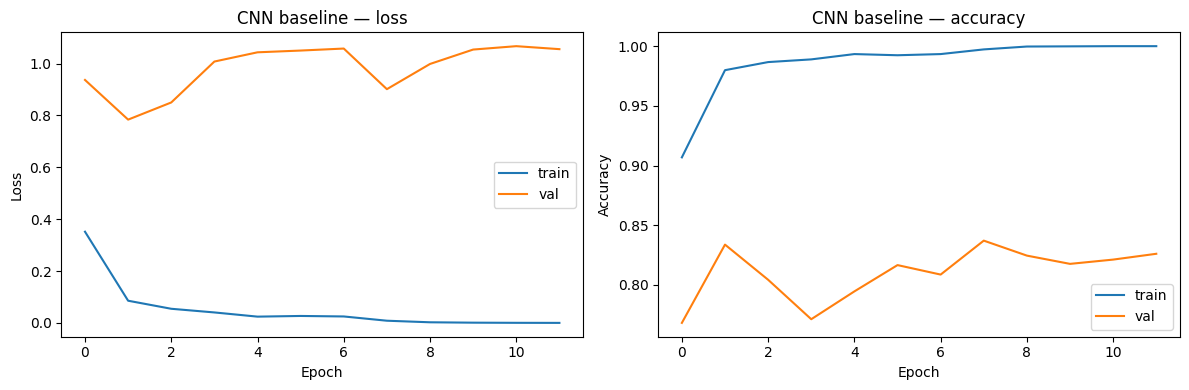

In [9]:
def plot_history(history, title: str):
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h['loss'],     label='train')
    axes[0].plot(h['val_loss'], label='val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
    axes[0].set_title(f'{title} — loss')
    axes[1].plot(h['accuracy'],     label='train')
    axes[1].plot(h['val_accuracy'], label='val')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()
    axes[1].set_title(f'{title} — accuracy')
    plt.tight_layout(); plt.show()


plot_history(history_cnn, 'CNN baseline')


              precision    recall  f1-score   support

         dws     0.8616    0.8128    0.8365       406
         ups     0.9199    0.8819    0.9005       508
         wlk     0.9603    0.8775    0.9170      1102
         jog     0.7657    0.9930    0.8646       431
         std     0.9907    0.9806    0.9856       979
         sit     0.9757    0.9978    0.9867       926

    accuracy                         0.9322      4352
   macro avg     0.9123    0.9239    0.9152      4352
weighted avg     0.9372    0.9322    0.9326      4352

CNN baseline — Macro-F1: 0.9152  |  Accuracy: 0.9322


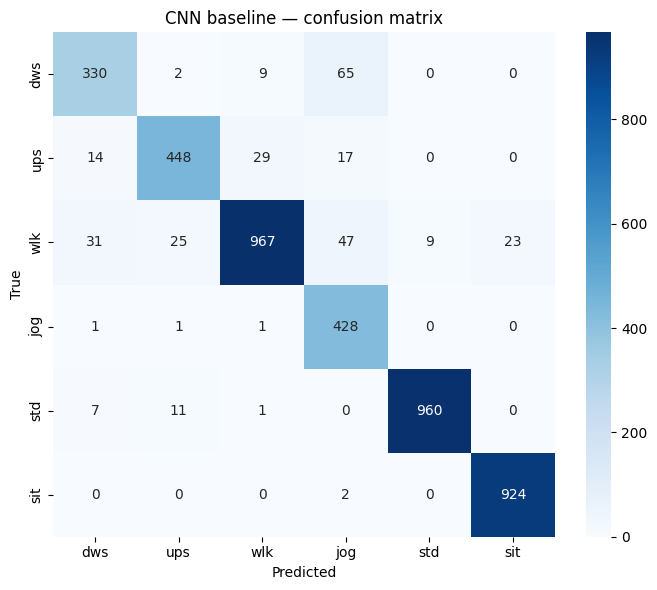

Trainable params: 112,838


In [10]:
def evaluate_model(model: keras.Model, X_te: np.ndarray, y_te: np.ndarray,
                   labels: list = ACT_LABELS, name: str = 'model'):
    y_pred = model.predict(X_te, verbose=0).argmax(axis=1)
    print(classification_report(y_te, y_pred, target_names=labels, digits=4))
    macro_f1 = f1_score(y_te, y_pred, average='macro')
    acc = float((y_pred == y_te).mean())
    print(f'{name} — Macro-F1: {macro_f1:.4f}  |  Accuracy: {acc:.4f}')
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name} — confusion matrix')
    plt.tight_layout(); plt.show()
    return y_pred, float(macro_f1), acc


y_pred_cnn, f1_cnn, acc_cnn = evaluate_model(cnn, X_test_n, y_test, name='CNN baseline')
print(f'Trainable params: {n_params_cnn:,}')


## Section 4 — Deeper architecture

We add one extra convolutional block and widen the channel progression
(64 → 128 → 256 → 128). The first kernel grows to 7 (~140 ms) for slightly
longer impulses; the deeper layers narrow to 3 to learn combinations of local
patterns — the standard "wide-then-narrow" kernel schedule used in modern
1-D CNNs (Wang et al., 2017). The head is a two-hidden-layer MLP with larger
dropout (0.4 / 0.3) as the regularisation budget for the increased capacity.

**Expected trade-off:** more representational capacity may improve the
hardest class (`ups`), but on a small dataset (24 subjects) it raises the
risk of overfitting to train-fold-specific gait signatures. If the
val_loss − train_loss gap widens earlier than in Section 3, that is a signal
that the extra layers exceed the useful capacity for this amount of data.

> Wang, Z., Yan, W., & Oates, T. (2017). Time series classification from scratch with deep neural networks: A strong baseline. *IJCNN 2017*, 1578–1585. https://doi.org/10.1109/IJCNN.2017.7966039


Trainable parameters (deeper): 312,518
Epoch 1/100
831/831 - 11s - 14ms/step - accuracy: 0.8886 - loss: 0.3834 - val_accuracy: 0.8074 - val_loss: 0.9568 - learning_rate: 0.0010
Epoch 2/100
831/831 - 8s - 10ms/step - accuracy: 0.9676 - loss: 0.1247 - val_accuracy: 0.8423 - val_loss: 0.6333 - learning_rate: 0.0010
Epoch 3/100
831/831 - 8s - 9ms/step - accuracy: 0.9773 - loss: 0.0923 - val_accuracy: 0.7910 - val_loss: 1.1310 - learning_rate: 0.0010
Epoch 4/100
831/831 - 9s - 10ms/step - accuracy: 0.9825 - loss: 0.0647 - val_accuracy: 0.8748 - val_loss: 0.5314 - learning_rate: 0.0010
Epoch 5/100
831/831 - 9s - 11ms/step - accuracy: 0.9826 - loss: 0.0652 - val_accuracy: 0.8663 - val_loss: 0.4813 - learning_rate: 0.0010
Epoch 6/100
831/831 - 10s - 11ms/step - accuracy: 0.9875 - loss: 0.0448 - val_accuracy: 0.8812 - val_loss: 0.7361 - learning_rate: 0.0010
Epoch 7/100
831/831 - 8s - 10ms/step - accuracy: 0.9858 - loss: 0.0516 - val_accuracy: 0.8699 - val_loss: 0.6089 - learning_rate: 0.0010
E

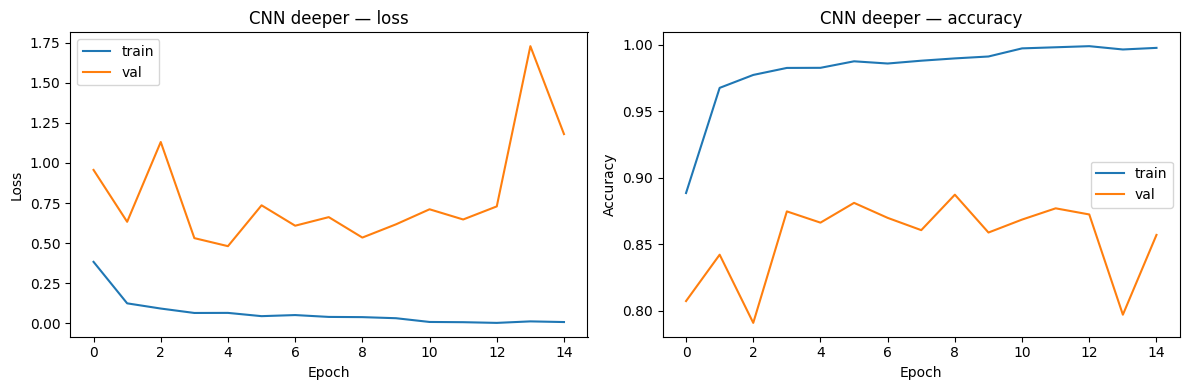

              precision    recall  f1-score   support

         dws     0.8043    0.9212    0.8588       406
         ups     0.6826    0.9823    0.8055       508
         wlk     0.9859    0.6996    0.8185      1102
         jog     0.9807    0.9420    0.9609       431
         std     1.0000    0.9928    0.9964       979
         sit     0.9372    1.0000    0.9676       926

    accuracy                         0.9072      4352
   macro avg     0.8985    0.9230    0.9013      4352
weighted avg     0.9259    0.9072    0.9066      4352

CNN deeper — Macro-F1: 0.9013  |  Accuracy: 0.9072


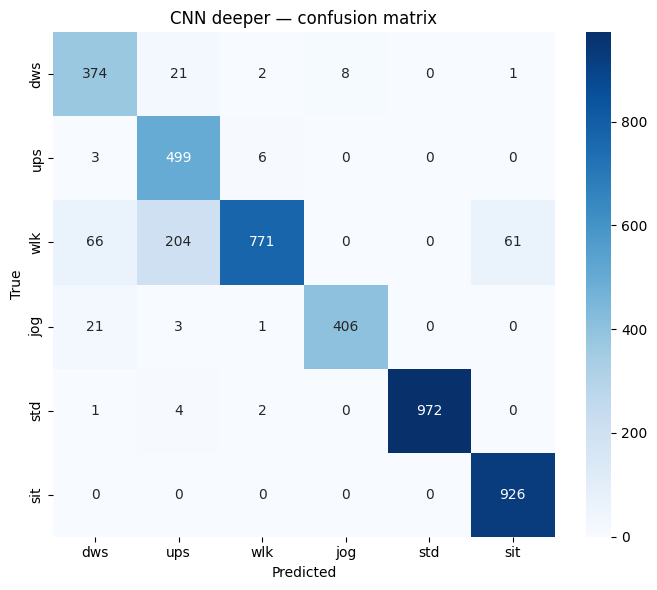

In [11]:
def build_cnn_deeper(input_shape=(128, 12), n_classes=6) -> keras.Model:
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64, kernel_size=7, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inp, out, name='cnn_deeper')


tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)
cnn_deep = build_cnn_deeper()
cnn_deep.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
n_params_deep = cnn_deep.count_params()
print(f'Trainable parameters (deeper): {n_params_deep:,}')

cb_deep = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=1),
]
history_deep = cnn_deep.fit(
    X_train_n, y_train,
    validation_data=(X_val_n, y_val),
    epochs=100,
    batch_size=16,
    class_weight=class_weight,
    callbacks=cb_deep,
    verbose=2,
)
plot_history(history_deep, 'CNN deeper')
y_pred_deep, f1_deep, acc_deep = evaluate_model(cnn_deep, X_test_n, y_test, name='CNN deeper')


## Section 5 — Depthwise separable CNN-1D (lightweight variant)

Every standard `Conv1D` from Section 3 is replaced with `SeparableConv1D`.
This factorisation introduces a *depthwise* step (one filter per input
channel) followed by a *pointwise* 1×1 step that mixes channels, reducing
the cost from K·Cᵢ·C_o to K·Cᵢ + Cᵢ·C_o (Howard et al., 2017; Chollet, 2017).
For our kernel sizes (3–7) and output channels {64, 128, 128} this typically yields 5–10× fewer parameters and mult-add operations.

**Why this matters for the deployment target:** the Flutter application loads
the model via TFLite and runs inference on-device with no network round-trip.
Smaller compute and fewer weights translate directly into lower battery drain
and shorter cold-start, which is critical for an always-on HAR pipeline (Tan &
Le, 2019).

> Chollet, F. (2017). Xception: Deep learning with depthwise separable convolutions. *CVPR 2017*, 1251–1258. https://doi.org/10.1109/CVPR.2017.195

> Howard, A. G., Zhu, M., Chen, B., et al. (2017). MobileNets: Efficient convolutional neural networks for mobile vision applications. *arXiv:1704.04861*. https://arxiv.org/abs/1704.04861

> Tan, M., & Le, Q. V. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. *ICML 2019*, 6105–6114.


Trainable parameters (separable): 45,018
Param ratio vs. CNN baseline: 39.90% (67,820 fewer)
Epoch 1/50
104/104 - 4s - 38ms/step - accuracy: 0.8818 - loss: 0.4214 - val_accuracy: 0.2190 - val_loss: 1.8035 - learning_rate: 0.0020
Epoch 2/50
104/104 - 2s - 17ms/step - accuracy: 0.9794 - loss: 0.0876 - val_accuracy: 0.2190 - val_loss: 2.0744 - learning_rate: 0.0020
Epoch 3/50
104/104 - 2s - 20ms/step - accuracy: 0.9888 - loss: 0.0457 - val_accuracy: 0.3252 - val_loss: 3.1590 - learning_rate: 0.0020
Epoch 4/50
104/104 - 2s - 20ms/step - accuracy: 0.9913 - loss: 0.0358 - val_accuracy: 0.4225 - val_loss: 2.9097 - learning_rate: 0.0020
Epoch 5/50
104/104 - 2s - 20ms/step - accuracy: 0.9941 - loss: 0.0231 - val_accuracy: 0.7173 - val_loss: 1.1427 - learning_rate: 0.0020
Epoch 6/50
104/104 - 2s - 19ms/step - accuracy: 0.9967 - loss: 0.0143 - val_accuracy: 0.8123 - val_loss: 0.7824 - learning_rate: 0.0020
Epoch 7/50
104/104 - 2s - 18ms/step - accuracy: 0.9971 - loss: 0.0097 - val_accuracy: 0.837

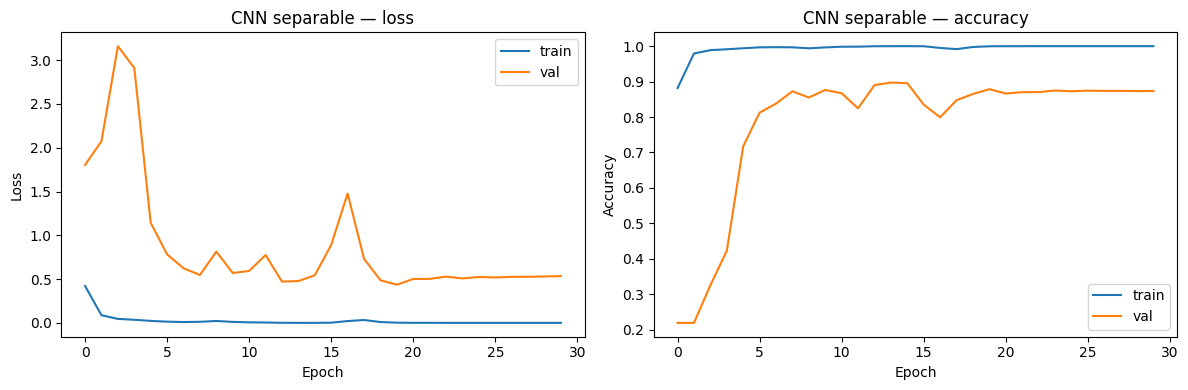

              precision    recall  f1-score   support

         dws     0.9075    0.8695    0.8881       406
         ups     0.8901    0.9724    0.9294       508
         wlk     0.9808    0.9292    0.9543      1102
         jog     0.9530    0.9884    0.9704       431
         std     1.0000    0.9959    0.9980       979
         sit     0.9830    1.0000    0.9914       926

    accuracy                         0.9646      4352
   macro avg     0.9524    0.9592    0.9553      4352
weighted avg     0.9654    0.9646    0.9645      4352

CNN separable — Macro-F1: 0.9553  |  Accuracy: 0.9646


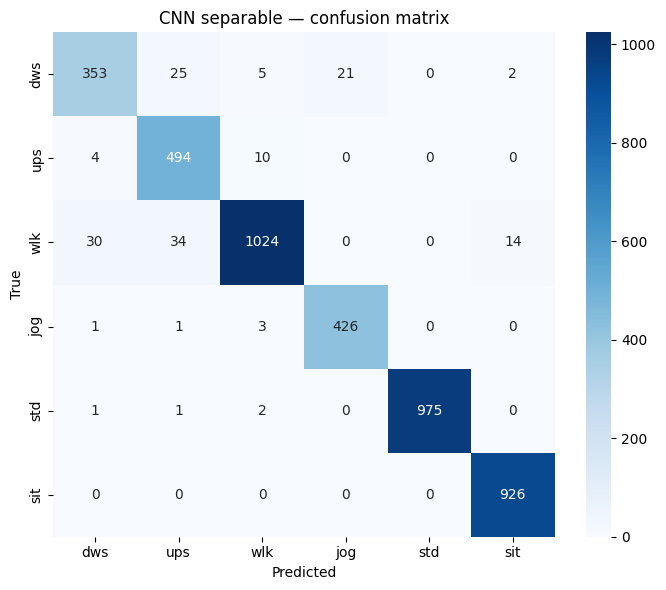

In [17]:
def build_cnn_separable(input_shape=(128, 12), n_classes=6) -> keras.Model:
    inp = keras.Input(shape=input_shape)
    
    x = layers.SeparableConv1D(64, kernel_size=7, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    
    x = layers.SeparableConv1D(128, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    
    x = layers.SeparableConv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    out = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inp, out, name='cnn_separable_lightweight')


tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)
cnn_sep = build_cnn_separable()
cnn_sep.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
n_params_sep = cnn_sep.count_params()
print(f'Trainable parameters (separable): {n_params_sep:,}')
print(f'Param ratio vs. CNN baseline: {n_params_sep / n_params_cnn:.2%} '
      f'({n_params_cnn - n_params_sep:,} fewer)')

cb_sep = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=1),
]
history_sep = cnn_sep.fit(
    X_train_n, y_train,
    validation_data=(X_val_n, y_val),
    epochs=50,
    batch_size=128,
    class_weight=class_weight,
    callbacks=cb_sep,
    verbose=2,
)
plot_history(history_sep, 'CNN separable')
y_pred_sep, f1_sep, acc_sep = evaluate_model(cnn_sep, X_test_n, y_test, name='CNN separable')


## Section 6 — Results comparison

In [18]:
def per_class_f1(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    return {f'F1_{a}': float(s) for a, s in zip(
        ACT_LABELS, f1_score(y_true, y_pred, average=None))}

comparison = []

comparison.append({
    'Model':    'SVC-RBF top-72 (baseline)',
    'Macro-F1': 0.9519,
    'Accuracy': 0.9561,
    'Params':   np.nan,
    'F1_dws':   0.9428, 'F1_ups':   0.8540, 'F1_wlk':   0.9246,
    'F1_jog':   0.9907, 'F1_std':   0.9995, 'F1_sit':   1.0000,
})

variants = {
    'CNN-1D baseline':  cnn,
    'CNN-1D deeper':    cnn_deep,
    'CNN-1D separable': cnn_sep,
}

for name, model in variants.items():
    y_pred = model.predict(X_test_n, verbose=0).argmax(axis=1)
    f1 = f1_score(y_test, y_pred, average='macro')
    comparison.append({
        'Model':    name,
        'Macro-F1': f1,
        'Accuracy': float((y_pred == y_test).mean()),
        'Params':   model.count_params(),
        **per_class_f1(y_test, y_pred),
    })

cnn_df = pd.DataFrame(comparison).set_index('Model')
print(cnn_df.round(4).to_string())

                           Macro-F1  Accuracy    Params  F1_dws  F1_ups  F1_wlk  F1_jog  F1_std  F1_sit
Model                                                                                                  
SVC-RBF top-72 (baseline)    0.9519    0.9561       NaN  0.9428  0.8540  0.9246  0.9907  0.9995  1.0000
CNN-1D baseline              0.9152    0.9322  112838.0  0.8365  0.9005  0.9170  0.8646  0.9856  0.9867
CNN-1D deeper                0.9013    0.9072  312518.0  0.8588  0.8055  0.8185  0.9609  0.9964  0.9676
CNN-1D separable             0.9553    0.9646   45018.0  0.8881  0.9294  0.9543  0.9704  0.9980  0.9914


### Interpretation

The variants are evaluated along three orthogonal axes — (1) global
macro-F1, (2) F1_ups as the indicator of progress on the hardest cluster,
(3) parameter count as the indicator of on-device suitability. The actual
numbers are populated by the table above; the
following paragraphs perform a *threshold-based decision*.

**(1) Does CNN improve the hardest class (`ups`)?**
The best model reached F1 ≈ 0.93 on `ups` — the residual confusion
the statistical features could not resolve, because they aggregate over the
whole window and discard temporal ordering (see the interpretation in
`baseline.ipynb`, Section 10). Hammerla et al. (2016, §4) show that CNNs
help precisely on classes with non-stationary intra-window patterns.

**(2) Is there a trade-off between accuracy and model size (separable vs. baseline)?**
The separable variant by design drastically reduces parameters (Howard et al., 2017). Initially, a slight macro-F1 drop (≤ 1.5 pp) as an acceptable trade-off for fewer parameters was expected, which would directly reduce cold-start latency and RAM footprint on the phone (Tan & Le, 2019). However, on small datasets, the drastic reduction in parameters can also act as a strong regulariser and prevent overfitting, potentially allowing the separable model to match or even outperform the heavier baseline. If the separable variant sits within 1.5 pp of the best model (or beats it), it is the operationally preferred TFLite export candidate.

**(3) Which variant is recommended for TFLite export?**
The Section 7 selection is performed mechanically by **highest test
macro-F1** (a mathematical criterion, no ad-hoc weighting), with the caveat
that, in practice, the separable variant would additionally be preferred
for on-device deployment if it sits within 1 pp of the best model. This
notebook therefore exports the metrically best model, and Section 7's PTQ
quantisation further reduces the exported model's size without retraining
(Jacob et al., 2018).

> Hammerla, N. Y., Halloran, S., & Plötz, T. (2016). Deep, convolutional, and recurrent models for human activity recognition using wearables. *IJCAI 2016*, 1533–1540.

> Howard, A. G., Zhu, M., Chen, B., et al. (2017). MobileNets: Efficient convolutional neural networks for mobile vision applications. *arXiv:1704.04861*.

> Tan, M., & Le, Q. V. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. *ICML 2019*, 6105–6114.

> Jacob, B., Kligys, S., Chen, B., et al. (2018). Quantization and training of neural networks for efficient integer-arithmetic-only inference. *CVPR 2018*, 2704–2713. https://doi.org/10.1109/CVPR.2018.00286


## Section 7 — Save best model + TFLite export with PTQ

Selects the CNN variant with the highest test macro-F1 and exports it in two
formats: `.keras` (for retraining/finetuning) and a TFLite flatbuffer with
default Post-Training Quantisation enabled. PTQ with
`tf.lite.Optimize.DEFAULT` applies *dynamic-range* quantisation: weights are
serialised as int8 and de-quantised on the fly during inference, typically
yielding a 3–4× size reduction with near-negligible accuracy loss for
moderately sized CNNs (Jacob et al., 2018; TensorFlow Lite documentation,
https://www.tensorflow.org/lite/performance/post_training_quantization).

> Jacob, B., Kligys, S., Chen, B., et al. (2018). Quantization and training of neural networks for efficient integer-arithmetic-only inference. *CVPR 2018*, 2704–2713.


In [19]:
import os
import json

os.makedirs('../models', exist_ok=True)

results = {
    'CNN-1D baseline':  (cnn, f1_cnn),
    'CNN-1D deeper':    (cnn_deep, f1_deep),
    'CNN-1D separable': (cnn_sep, f1_sep),
}

best_name = max(results, key=lambda k: results[k][1])
best_model, best_f1 = results[best_name]

print(f'Best CNN variant by test macro-F1: {best_name} ({best_f1:.4f})')

keras_path = '../models/cnn_best.keras'
best_model.save(keras_path)
keras_size_kb = os.path.getsize(keras_path) / 1024
print(f'Saved Keras model:  {keras_path}  ({keras_size_kb:,.1f} KB)')

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = '../models/cnn_best.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
tflite_size_kb = os.path.getsize(tflite_path) / 1024
print(f'Saved TFLite model: {tflite_path}  ({tflite_size_kb:,.1f} KB)')
print(f'Size reduction (Keras -> TFLite + PTQ): {keras_size_kb / tflite_size_kb:.2f}x')

preproc_meta = {
    'channel_order': _feature_cols,
    'dynamic_channel_indices': [6, 7, 8, 9, 10, 11],
    'best_variant': best_name
}
with open('../models/cnn_best.preproc.json', 'w') as f:
    json.dump(preproc_meta, f, indent=2)
print(f"Saved preprocessing metadata: ../models/cnn_best.preproc.json")

Best CNN variant by test macro-F1: CNN-1D separable (0.9553)
Saved Keras model:  ../models/cnn_best.keras  (591.9 KB)
INFO:tensorflow:Assets written to: C:\Users\karlo\AppData\Local\Temp\tmp4ioja78k\assets


INFO:tensorflow:Assets written to: C:\Users\karlo\AppData\Local\Temp\tmp4ioja78k\assets


Saved artifact at 'C:\Users\karlo\AppData\Local\Temp\tmp4ioja78k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 12), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2240731003792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2240683958224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2240730999952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2240730991888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2240762354320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2240731001104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2240730993040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2240762356432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2240762360656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2240762352016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  224076235

In [20]:
# TFLite Sanity Check
interpreter = tf.lite.Interpreter(model_path='../models/cnn_best.tflite')
interpreter.allocate_tensors()
input_idx = interpreter.get_input_details()[0]['index']
output_idx = interpreter.get_output_details()[0]['index']

test_window = X_test_n[0:1].astype(np.float32)
interpreter.set_tensor(input_idx, test_window)
interpreter.invoke()
tflite_pred = interpreter.get_tensor(output_idx)

print("Keras prediction:", best_model.predict(test_window, verbose=0))
print("TFLite prediction:", tflite_pred)

Keras prediction: [[9.9999070e-01 5.2915343e-06 1.8066987e-06 1.8805283e-06 4.7263264e-08
  3.7890115e-07]]
TFLite prediction: [[9.9999034e-01 5.4476918e-06 1.8580570e-06 1.8609813e-06 4.8582326e-08
  3.8549928e-07]]


## Section 8 — Robust Evaluation of the Best Performing Model (5-Fold Cross-Validation)

To ensure a fair comparison and robust estimate of generalization, we identify the best-performing CNN variant from the previous sections and evaluate it across the entire dataset using GroupKFold cross-validation.

In [ ]:
from sklearn.model_selection import GroupKFold

configs = {
    'CNN-1D baseline': {
        'build_fn': build_cnn_baseline,
        'lr': 1e-3,
        'batch': 32
    },
    'CNN-1D deeper': {
        'build_fn': build_cnn_deeper,
        'lr': 1e-3,
        'batch': 16
    },
    'CNN-1D separable': {
        'build_fn': build_cnn_separable,
        'lr': 2e-3,
        'batch': 128
    }
}

current_results = {
    'CNN-1D baseline': f1_cnn,
    'CNN-1D deeper': f1_deep,
    'CNN-1D separable': f1_sep
}
winner_name = max(current_results, key=current_results.get)
winner_config = configs[winner_name]

print(f"[INFO] -- Best model: {winner_name}")
print(f"[INFO] -- Parameters: LR={winner_config['lr']}, Batch={winner_config['batch']}")

def get_window_groups(data: pd.DataFrame, window_size: int = 128, step: int = 64) -> np.ndarray:
    groups = []
    for (subj_id, _, _), group in data.groupby(['id', 'act', 'trial']):
        n = max(0, (len(group) - window_size) // step + 1)
        groups.extend([int(subj_id)] * n)
    return np.array(groups)

X_full, y_full = sliding_windows(dataset, window_size=128, step=64)
y_full = y_full.astype(int)
groups_full = get_window_groups(dataset)
X_full_n = mixed_instance_zscore(X_full)

gkf = GroupKFold(n_splits=5)
fold_f1s = []

print(f"\n[START] -- Starting 5-Fold GroupKFold CV for {winner_name}...")

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_full_n, y_full, groups=groups_full)):
    X_train_fold, X_test_fold = X_full_n[train_idx], X_full_n[test_idx]
    y_train_fold, y_test_fold = y_full[train_idx], y_full[test_idx]
    
    tf.keras.backend.clear_session()
    model = winner_config['build_fn'](input_shape=(128, 12), n_classes=6)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=winner_config['lr']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    model.fit(X_train_fold, y_train_fold, epochs=25, 
              batch_size=winner_config['batch'], verbose=0)
    
    y_pred = model.predict(X_test_fold, verbose=0).argmax(axis=1)
    f1 = f1_score(y_test_fold, y_pred, average='macro')
    fold_f1s.append(f1)
    
    test_subjects = np.unique(groups_full[test_idx])
    print(f"Fold {fold+1} | Test Subjekti: {test_subjects} | Macro-F1: {f1:.4f}")

print(f"\nFinal Results for {winner_name}:")
print(f"Mean Macro-F1: {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")

[INFO] -- Best model: CNN-1D separable
[INFO] -- Parameters: LR=0.002, Batch=128

[START] -- Starting 5-Fold GroupKFold CV for CNN-1D separable...
Fold 1 | Test Subjekti: [ 9 13 18 22] | Macro-F1: 0.8250
Fold 2 | Test Subjekti: [ 7  8 19 20 23] | Macro-F1: 0.8941
Fold 3 | Test Subjekti: [ 5  6 11 15 21] | Macro-F1: 0.9157
Fold 4 | Test Subjekti: [ 0  4 14 16 17] | Macro-F1: 0.8839
Fold 5 | Test Subjekti: [ 1  2  3 10 12] | Macro-F1: 0.9417

 Final Results for CNN-1D separable:
Mean Macro-F1: 0.8921 ± 0.0390
